<a href="https://colab.research.google.com/github/mdanmek/nida-dads-notes/blob/main/dads5001-data-tools/project/eda/03_construction_eda_2569.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# การสำรวจโครงการจ้างก่อสร้างและการกำหนดกลุ่มศึกษา ปีงบประมาณ 2569

ข้อมูล e-GP ปีงบประมาณ 2569 สะสมถึงวันที่ 30 กรกฎาคม 2569 ไม่ใช่ข้อมูลเต็มปี

Notebook นี้ตอบคำถามตามลำดับดังนี้:

1. โครงการก่อสร้างส่วนใหญ่อยู่ในช่วงวงเงินใด
2. การกระจุกของวงเงินสัมพันธ์กับวิธีจัดซื้อใด
3. กฎหมายอธิบายการกระจุกดังกล่าวได้อย่างไร
4. ควรกำหนดกลุ่มศึกษาสำหรับค้นหา Pattern อย่างไร


In [57]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
from pathlib import Path
from matplotlib.patches import FancyBboxPatch

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)


In [59]:
base_dir = Path('/content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract')

data_path = base_dir / 'processed' / 'construction_contracts_2569.csv'
project_output_path = base_dir / 'processed' / 'construction_projects_2569.csv'

project_dir = base_dir.parents[2]
figure_dir = project_dir / 'figure'
figure_dir.mkdir(parents=True, exist_ok=True)

print(f'Input file: {data_path}')
print(f'Project output: {project_output_path}')
print(f'Figure directory: {figure_dir}')

Input file: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed/construction_contracts_2569.csv
Project output: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed/construction_projects_2569.csv
Figure directory: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure


In [60]:
# ดาวน์โหลดฟอนต์สำหรับแสดงภาษาไทยในกราฟ
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

fm.fontManager.addfont('thsarabunnew-webfont.ttf')

sns.set_theme(
    style='white',
    font='TH Sarabun New'
)

plt.rcParams.update({
    'axes.titlesize': 20,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 14,
    'axes.labelcolor': '#344054',
    'xtick.labelsize': 12,
    'ytick.labelsize': 13,
    'xtick.color': '#475467',
    'ytick.color': '#475467',
    'legend.fontsize': 12,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.unicode_minus': False
})

NAVY = '#355C7D'
BLUE = '#5B7FA3'
AMBER = '#D9822B'
GRAY = '#B8C2CC'
LIGHT_GRAY = '#EEF2F6'
TEXT = '#1F2937'
MUTED = '#667085'
GRID = '#E4E7EC'

## 1. สร้างข้อมูลระดับโครงการ

ไฟล์จาก Notebook 02 อยู่ในระดับ `โครงการ–สัญญา–บริษัท` การสำรวจวงเงินและวิธีจัดซื้อใน Notebook นี้ต้องใช้หนึ่งแถวต่อ `รหัสโครงการ`


In [61]:
construction_data = pd.read_csv(data_path, low_memory=False)

print(f'รายการจาก Notebook 02: {len(construction_data):,}')
print(f'จำนวนคอลัมน์: {construction_data.shape[1]:,}')

display(construction_data.head())

รายการจาก Notebook 02: 179,716
จำนวนคอลัมน์: 29


,ลำดับ,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อประเภทโครงการ,ชื่อหน่วยงาน,ชื่อหน่วยงานย่อย,ชื่อวิธีการจัดซื้อจัดจ้าง,ชื่อกลุ่มวิธีการจัดซื้อจัดจ้าง,วันที่ประกาศจัดซื้อจัดจ้าง,วงเงินงบประมาณ (บาท),ราคากลาง (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),ปีงบประมาณ,วันที่เกิดรายการ,จังหวัด,เขต/อำเภอ,แขวง/ตำบล,สถานะโครงการ,พิกัดของโครงการ,ละติจูดของโครงการ,ลองจิจูดของโครงการ,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,เลขที่สัญญา,วันที่ลงนามในสัญญา,วันที่สิ้นสุดสัญญา,วงเงินงบประมาณในสัญญา (บาท),สถานะสัญญา,source_file
0,2,67079254388,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างศูนย์การแ...,จ้างก่อสร้าง,กรุงเทพมหานคร,สำนักการโยธา กรุงเทพมหานคร,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,8 ก.ค. 68,"4,000,000,000.00","4,000,000,000.00","3,997,800,000.00",2569,7 ม.ค. 69,กรุงเทพมหานคร,ดินแดง,ดินแดง,ระหว่างดำเนินการ,POINT(100.51196175293 13.743704315315),13.74,100.51,0107537000939,บริษัท อิตาเลียนไทย ดีเวล๊อปเมนต์ จำกัด (มหาชน),กคส.สนย.๒๒-๕-๖๙,7 ม.ค. 69,26 พ.ค. 73,"3,997,800,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
1,3,68049277788,ประกวดราคาจ้างก่อสร้างโครงการเปลี่ยนระบบสายไฟฟ...,จ้างก่อสร้าง,การไฟฟ้านครหลวง,ฝ่ายบริหารโครงการ การไฟฟ้านครหลวง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,15 ก.ย. 68,"4,083,120,000.00","3,872,008,000.00","3,870,550,927.00",2569,29 เม.ย. 69,กรุงเทพมหานคร,คลองเตย,คลองเตย,ระหว่างดำเนินการ,"POLYGON((100.64566612244 13.762437066514,100.6...",13.79,100.69,0993000532988,กิจการร่วมค้า จีบีที,MP8-3404-ABL,29 เม.ย. 69,-,"3,870,550,927.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
2,5,68109204474,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างสถาบันมะเ...,จ้างก่อสร้าง,สถาบันมะเร็งแห่งชาติ,สถาบันมะเร็งแห่งชาติ,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,6 ม.ค. 69,"3,300,000,000.00","3,407,005,257.46","3,285,000,000.00",2569,10 มิ.ย. 69,กรุงเทพมหานคร,ราชเทวี,ทุ่งพญาไท,ระหว่างดำเนินการ,"POLYGON((100.41905164719 13.570553229914,100.4...",13.57,100.42,0107547000273,บริษัท เอ็นแอล ดีเวลลอปเมนต์ จำกัด (มหาชน),192/2569 (พ),10 มิ.ย. 69,15 พ.ค. 74,"3,285,000,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
3,6,68069459174,ประกวดราคาจ้างก่อสร้างโครงการเปลี่ยนระบบสายไฟฟ...,จ้างก่อสร้าง,การไฟฟ้านครหลวง,ฝ่ายบริหารโครงการ การไฟฟ้านครหลวง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,28 พ.ย. 68,"3,370,500,000.00","3,285,232,000.00","3,282,800,000.00",2569,29 มิ.ย. 69,กรุงเทพมหานคร,คลองเตย,คลองเตย,ระหว่างดำเนินการ,"LINESTRING(100.62686920166 13.926236380743,100...",13.88,100.60,0993000536215,กิจการร่วมค้า เอสดับเบิ้ลยูซี,MP8-3402-ABL,29 มิ.ย. 69,10 ธ.ค. 72,"3,282,800,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
4,7,67099642340,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างปรับปรุงข...,จ้างก่อสร้าง,การประปาส่วนภูมิภาค,กองจัดหา การประปาส่วนภูมิภาค,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,16 ก.ค. 68,"3,498,760,900.00","3,498,752,340.00","3,250,900,000.00",2569,20 พ.ย. 68,กรุงเทพมหานคร,หลักสี่,ตลาดบางเขน,ระหว่างดำเนินการ,POINT(98.5303660281 8.4326626992),8.43,98.53,0105519003571,บริษัท วงษ์สยามก่อสร้าง จำกัด,กจห.123/2568,20 พ.ย. 68,23 เม.ย. 71,"3,250,900,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv


In [62]:
project_id_column = 'รหัสโครงการ'
budget_column = 'วงเงินงบประมาณ (บาท)'
method_column = 'ชื่อวิธีการจัดซื้อจัดจ้าง'

project_columns = [
    project_id_column,
    'ชื่อโครงการจัดซื้อจัดจ้าง',
    'ชื่อประเภทโครงการ',
    'ชื่อหน่วยงาน',
    'ชื่อหน่วยงานย่อย',
    method_column,
    'ชื่อกลุ่มวิธีการจัดซื้อจัดจ้าง',
    'วันที่ประกาศจัดซื้อจัดจ้าง',
    budget_column,
    'ราคากลาง (บาท)',
    'ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท)',
    'ปีงบประมาณ',
    'วันที่เกิดรายการ',
    'จังหวัด',
    'เขต/อำเภอ',
    'แขวง/ตำบล',
    'สถานะโครงการ',
    'พิกัดของโครงการ',
    'ละติจูดของโครงการ',
    'ลองจิจูดของโครงการ'
]

In [63]:
project_data = construction_data[project_columns].drop_duplicates(subset=project_id_column,keep='first').copy()

project_data[budget_column] = pd.to_numeric(project_data[budget_column], errors='coerce')

print(f'รายการระดับสัญญา–บริษัท: {len(construction_data):,}')
print(f'โครงการไม่ซ้ำ: {len(project_data):,}')
print(f'แถวที่รวมเป็นระดับโครงการ: {len(construction_data) - len(project_data):,}')

รายการระดับสัญญา–บริษัท: 179,716
โครงการไม่ซ้ำ: 178,978
แถวที่รวมเป็นระดับโครงการ: 738


ข้อมูลสำหรับ EDA เหลือหนึ่งแถวต่อโครงการ ส่วนข้อมูลผู้รับจ้างยังอยู่ในไฟล์จาก Notebook 02 และจะใช้เลขประจำตัวนิติบุคคลเป็นคีย์ใน Notebook 04


## 2. โครงการก่อสร้างส่วนใหญ่อยู่ช่วงใด

เริ่มจากดูค่ากลาง ช่วงวงเงิน และวงเงินที่พบซ้ำบ่อย โดยยังไม่ใช้กฎหมายเป็นจุดตั้งต้น


In [64]:
budget_summary = project_data[budget_column].describe(percentiles=[0.25, 0.50, 0.75, 0.95, 0.99])

display(budget_summary.to_frame(name='วงเงินงบประมาณ'))

print(f'Mean: {project_data[budget_column].mean():,.0f} บาท')
print(f'Median: {project_data[budget_column].median():,.0f} บาท')
print(f'99th percentile: {project_data[budget_column].quantile(0.99):,.0f} บาท')

,วงเงินงบประมาณ
count,"178,978.00"
mean,"2,659,155.23"
std,"30,273,037.92"
min,900.00
25%,"181,100.00"
50%,"395,000.00"
75%,"500,000.00"
95%,"9,751,915.00"
99%,"32,500,000.00"
max,"4,083,120,000.00"


Mean: 2,659,155 บาท
Median: 395,000 บาท
99th percentile: 32,500,000 บาท


In [65]:
common_budget_values = (
    project_data[budget_column]
    .value_counts()
    .head(15)
    .rename_axis('วงเงินงบประมาณ')
    .reset_index(name='จำนวนโครงการ')
)

common_budget_values['สัดส่วนโครงการ (%)'] = (common_budget_values['จำนวนโครงการ'] / len(project_data) * 100)

display(common_budget_values)

,วงเงินงบประมาณ,จำนวนโครงการ,สัดส่วนโครงการ (%)
0,"500,000.00",6523,3.64
1,"499,000.00",3593,2.01
2,"200,000.00",2527,1.41
3,"498,000.00",2438,1.36
4,"300,000.00",2266,1.27
5,"100,000.00",1991,1.11
6,"490,000.00",1790,1.00
7,"150,000.00",1527,0.85
8,"495,000.00",1525,0.85
9,"400,000.00",1481,0.83


In [66]:
budget_bins = [
    0,
    100_000,
    200_000,
    300_000,
    400_000,
    500_000,
    1_000_000,
    5_000_000,
    10_000_000,
    50_000_000,
    np.inf
]

budget_labels = [
    'ไม่เกิน 100,000',
    '100,001–200,000',
    '200,001–300,000',
    '300,001–400,000',
    '400,001–500,000',
    '500,001–1 ล้าน',
    'มากกว่า 1–5 ล้าน',
    'มากกว่า 5–10 ล้าน',
    'มากกว่า 10–50 ล้าน',
    'มากกว่า 50 ล้าน'
]

project_data['budget_band'] = pd.cut(
    project_data[budget_column],
    bins=budget_bins,
    labels=budget_labels,
    include_lowest=True
)

In [67]:
budget_band_summary = (
    project_data
    .groupby('budget_band', observed=False)
    .agg(
        project_count=(project_id_column, 'size'),
        total_budget=(budget_column, 'sum')
    )
    .reset_index()
)

budget_band_summary['project_pct'] = (
    budget_band_summary['project_count']
    / len(project_data)
    * 100
)

budget_band_summary['budget_pct'] = (
    budget_band_summary['total_budget']
    / budget_band_summary['total_budget'].sum()
    * 100
)

display(budget_band_summary)


,budget_band,project_count,total_budget,project_pct,budget_pct
0,"ไม่เกิน 100,000",23393,"1,391,944,502.51",13.07,0.29
1,"100,001–200,000",27835,"4,244,799,665.13",15.55,0.89
2,"200,001–300,000",22675,"5,754,249,900.83",12.67,1.21
3,"300,001–400,000",17815,"6,284,080,423.64",9.95,1.32
4,"400,001–500,000",44905,"21,508,548,791.78",25.09,4.52
5,"500,001–1 ล้าน",8171,"6,142,652,360.00",4.57,1.29
6,มากกว่า 1–5 ล้าน,18981,"49,057,947,604.33",10.61,10.31
7,มากกว่า 5–10 ล้าน,7899,"61,201,364,790.37",4.41,12.86
8,มากกว่า 10–50 ล้าน,6421,"138,630,828,482.95",3.59,29.13
9,มากกว่า 50 ล้าน,883,"181,713,868,683.13",0.49,38.18


/tmp/ipykernel_3349/1878714528.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.06, 0.05, 1, 0.94])


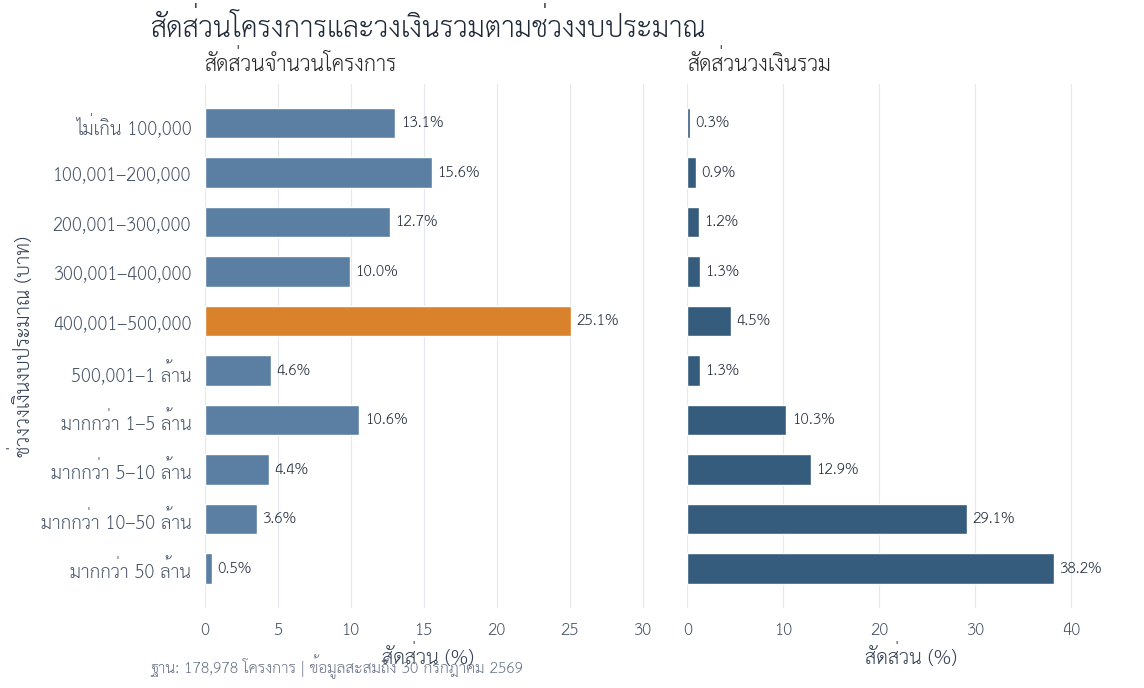

In [68]:
plot_data = budget_band_summary.copy()
y = np.arange(len(plot_data))
highlight_band = '400,001–500,000'

count_colors = [
    AMBER if str(band) == highlight_band else BLUE
    for band in plot_data['budget_band']
]

fig, axes = plt.subplots(
    ncols=2,
    figsize=(12, 6.8),
    sharey=True,
    gridspec_kw={'wspace': 0.08}
)

count_bars = axes[0].barh(
    y,
    plot_data['project_pct'],
    color=count_colors,
    height=0.62
)

value_bars = axes[1].barh(
    y,
    plot_data['budget_pct'],
    color=NAVY,
    height=0.62
)

for ax, bars, values, panel_title in zip(
    axes,
    [count_bars, value_bars],
    [plot_data['project_pct'], plot_data['budget_pct']],
    ['สัดส่วนจำนวนโครงการ', 'สัดส่วนวงเงินรวม']
):
    ax.bar_label(
        bars,
        labels=[f'{value:.1f}%' for value in values],
        padding=4,
        fontsize=11,
        color=TEXT
    )
    ax.set_title(panel_title, loc='left', fontsize=15, pad=10)
    ax.set_xlabel('สัดส่วน (%)')
    ax.set_xlim(0, max(values.max() * 1.22, 30))
    ax.grid(axis='x', color=GRID, linewidth=0.8)
    ax.grid(axis='y', visible=False)
    ax.set_axisbelow(True)
    sns.despine(ax=ax, left=True, bottom=True)

axes[0].set_yticks(y)
axes[0].set_yticklabels(plot_data['budget_band'])
axes[0].invert_yaxis()
axes[0].set_ylabel('ช่วงวงเงินงบประมาณ (บาท)')
axes[1].tick_params(axis='y', left=False, labelleft=False)

fig.suptitle(
    'สัดส่วนโครงการและวงเงินรวมตามช่วงงบประมาณ',
    x=0.08,
    y=0.99,
    ha='left',
    fontsize=20,
    fontweight='semibold',
    color=TEXT
)

fig.text(
    0.08,
    0.015,
    f'ฐาน: {len(project_data):,} โครงการ | ข้อมูลสะสมถึง 30 กรกฎาคม 2569',
    fontsize=11,
    color=MUTED
)

fig.tight_layout(rect=[0.06, 0.05, 1, 0.94])

In [69]:
png_path = figure_dir / 'fig03_01_project_and_budget_share_by_budget_band.png'
svg_path = figure_dir / 'fig03_01_project_and_budget_share_by_budget_band.svg'

fig.savefig(png_path, dpi=180, bbox_inches='tight', facecolor='white')
fig.savefig(svg_path, bbox_inches='tight', facecolor='white')

print(f'Saved: {png_path}')
print(f'Saved: {svg_path}')

Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_01_project_and_budget_share_by_budget_band.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_01_project_and_budget_share_by_budget_band.svg


### สิ่งที่พบ

วงเงินมัธยฐานอยู่ที่ 395,000 บาท ขณะที่ค่าเฉลี่ยประมาณ 2.66 ล้านบาท แสดงว่าการกระจายเบ้ขวาจากโครงการขนาดใหญ่จำนวนน้อย

โครงการไม่เกิน 500,000 บาทมี 136,623 โครงการ หรือ 76.34% ของโครงการทั้งหมด แต่ครองวงเงินรวมประมาณ 8.23% โดยช่วง 400,001–500,000 บาทมีจำนวนโครงการมากที่สุด และวงเงิน 500,000 บาทเป็นค่าที่พบซ้ำบ่อยที่สุด

คำถามถัดไปคือ การกระจุกของโครงการขนาดเล็กสัมพันธ์กับวิธีจัดซื้อใด


## 3. โครงการกระจุกบริเวณใดรอบ 500,000 บาท

ช่วง 400,000–550,000 บาทช่วยขยายภาพจากช่วงงบประมาณกว้างให้เห็นตำแหน่งการกระจุกก่อนนำไปเชื่อมกับวิธีจัดซื้อ

In [70]:
threshold_bands = [
    (400_000, 409_999, '400–409k'),
    (410_000, 419_999, '410–419k'),
    (420_000, 429_999, '420–429k'),
    (430_000, 439_999, '430–439k'),
    (440_000, 449_999, '440–449k'),
    (450_000, 459_999, '450–459k'),
    (460_000, 469_999, '460–469k'),
    (470_000, 479_999, '470–479k'),
    (480_000, 489_999, '480–489k'),
    (490_000, 500_000, '490–500k'),
    (500_001, 510_000, '500–510k'),
    (510_001, 520_000, '510–520k'),
    (520_001, 530_000, '520–530k'),
    (530_001, 540_000, '530–540k'),
    (540_001, 550_000, '540–550k')
]

threshold_results = []

for lower, upper, label in threshold_bands:
    project_count = project_data[budget_column].between(
        lower,
        upper,
        inclusive='both'
    ).sum()

    threshold_results.append({
        'ช่วงวงเงิน': label,
        'จำนวนโครงการ': project_count,
        'ต่ำกว่า/เท่ากับเพดาน': upper <= 500_000
    })

threshold_summary = pd.DataFrame(threshold_results)

display(threshold_summary)


,ช่วงวงเงิน,จำนวนโครงการ,ต่ำกว่า/เท่ากับเพดาน
0,400–409k,2864,True
1,410–419k,1386,True
2,420–429k,1775,True
3,430–439k,1393,True
4,440–449k,1612,True
5,450–459k,2251,True
6,460–469k,1872,True
7,470–479k,2416,True
8,480–489k,4576,True
9,490–500k,26240,True


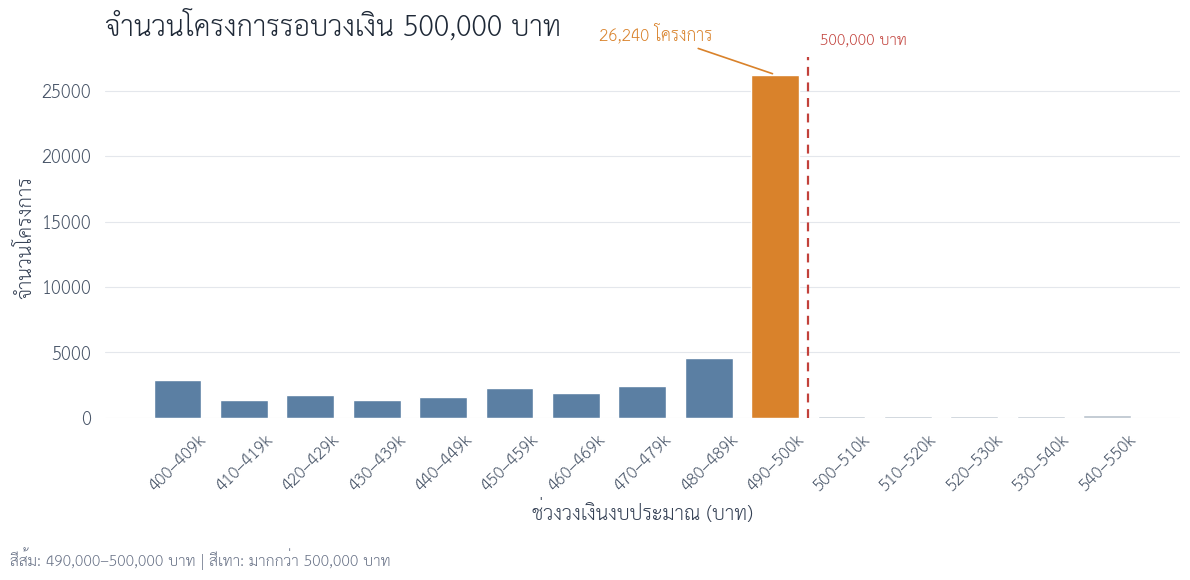

In [71]:
bar_colors = [
    AMBER if index == 9 else BLUE if index < 9 else GRAY
    for index in threshold_summary.index
]

fig, ax = plt.subplots(figsize=(12, 5.8))

bars = ax.bar(
    threshold_summary['ช่วงวงเงิน'],
    threshold_summary['จำนวนโครงการ'],
    color=bar_colors,
    width=0.72
)

peak_index = threshold_summary['จำนวนโครงการ'].idxmax()
peak_value = threshold_summary.loc[peak_index, 'จำนวนโครงการ']

ax.annotate(
    f'{peak_value:,.0f} โครงการ',
    xy=(peak_index, peak_value),
    xytext=(peak_index - 1.8, peak_value * 1.10),
    ha='center',
    fontsize=12,
    fontweight='semibold',
    color=AMBER,
    arrowprops={
        'arrowstyle': '-',
        'color': AMBER,
        'linewidth': 1.2
    }
)

ax.axvline(
    9.5,
    color='#C2413B',
    linestyle=(0, (4, 3)),
    linewidth=1.6
)

ax.text(
    9.68,
    peak_value * 1.12,
    '500,000 บาท',
    color='#C2413B',
    fontsize=11,
    va='top'
)

ax.set_title(
    'จำนวนโครงการรอบวงเงิน 500,000 บาท',
    loc='left',
    pad=16,
    color=TEXT
)
ax.set_xlabel('ช่วงวงเงินงบประมาณ (บาท)')
ax.set_ylabel('จำนวนโครงการ')
ax.tick_params(axis='x', rotation=45)

ax.grid(axis='y', color=GRID, linewidth=0.8)
ax.grid(axis='x', visible=False)
ax.set_axisbelow(True)
sns.despine(left=True, bottom=True)

fig.text(
    0.01,
    0.01,
    'สีส้ม: 490,000–500,000 บาท | สีเทา: มากกว่า 500,000 บาท',
    fontsize=11,
    color=MUTED
)

fig.tight_layout(rect=[0, 0.05, 1, 1])

In [72]:
png_path = figure_dir / 'fig03_02_budget_distribution_around_500k.png'
svg_path = figure_dir / 'fig03_02_budget_distribution_around_500k.svg'

fig.savefig(png_path, dpi=180, bbox_inches='tight', facecolor='white')
fig.savefig(svg_path, bbox_inches='tight', facecolor='white')

print(f'Saved: {png_path}')
print(f'Saved: {svg_path}')

Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_02_budget_distribution_around_500k.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_02_budget_distribution_around_500k.svg


In [73]:
near_threshold_windows = [
    (450_000, 500_000, '450,000–500,000'),
    (480_000, 500_000, '480,000–500,000'),
    (490_000, 500_000, '490,000–500,000'),
    (495_000, 500_000, '495,000–500,000')
]

window_results = []

for lower, upper, label in near_threshold_windows:
    project_count = study_project_data[budget_column].between(
        lower,
        upper,
        inclusive='both'
    ).sum()

    window_results.append({
        'ช่วงวงเงิน': label,
        'จำนวนโครงการ': project_count,
        'สัดส่วนกลุ่มศึกษา (%)': (
            project_count / len(study_project_data) * 100
        )
    })

near_threshold_summary = pd.DataFrame(window_results)

display(near_threshold_summary)


,ช่วงวงเงิน,จำนวนโครงการ,สัดส่วนกลุ่มศึกษา (%)
0,"450,000–500,000",37198,27.34
1,"480,000–500,000",30697,22.56
2,"490,000–500,000",26154,19.22
3,"495,000–500,000",20734,15.24


### สิ่งที่พบ

ช่วง 490,000–500,000 บาทมี 26,154 โครงการ สูงกว่าช่วงใกล้เคียงอย่างชัดเจน จึงเป็นจุดกระจุกที่ควรตรวจบริบทต่อ

500,000 บาทเป็นเส้นที่มาจากกฎหมาย ส่วน 490,000 บาทเป็นขอบล่างที่กำหนดเพื่อการศึกษา จึงยังไม่ตีความการกระจุกนี้ว่าเป็นความผิดปกติ

## 4. การกระจุกสัมพันธ์กับวิธีจัดซื้อใด

เมื่อพบการกระจุกบริเวณก่อนถึง 500,000 บาท ขั้นต่อไปคือเปรียบเทียบว่าแต่ละวิธีจัดซื้อมีบทบาทต่างกันอย่างไร โดยแยก “จำนวนโครงการ” ออกจาก “วงเงินรวม”

In [74]:
method_summary = (
    project_data
    .groupby(method_column)
    .agg(
        project_count=(project_id_column, 'size'),
        total_budget=(budget_column, 'sum'),
        median_budget=(budget_column, 'median')
    )
    .reset_index()
)

method_summary['project_pct'] = (method_summary['project_count'] / len(project_data) * 100)
method_summary['budget_pct'] = (method_summary['total_budget'] / method_summary['total_budget'].sum() * 100)
method_summary = method_summary.sort_values('project_count', ascending=False)

display(method_summary)

,ชื่อวิธีการจัดซื้อจัดจ้าง,project_count,total_budget,median_budget,project_pct,budget_pct
3,เฉพาะเจาะจง,136651,"44,405,304,186.95","283,000.00",76.35,9.33
2,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),37973,"396,653,793,876.02","3,097,500.00",21.22,83.34
0,คัดเลือก,4352,"34,870,707,141.70","2,736,650.00",2.43,7.33
1,ตกลงราคา,2,"480,000.00","240,000.00",0.00,0.00


In [75]:
method_names = {
    'เฉพาะเจาะจง': 'เฉพาะเจาะจง',
    'ประกวดราคาอิเล็กทรอนิกส์ (e-bidding)': 'e-bidding',
    'คัดเลือก': 'คัดเลือก'
}

method_plot = method_summary[
    method_summary[method_column].isin(method_names)
].copy()

method_plot['method_label'] = (
    method_plot[method_column]
    .map(method_names)
)


/tmp/ipykernel_3349/1483508662.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.07, 0.06, 1, 0.93])


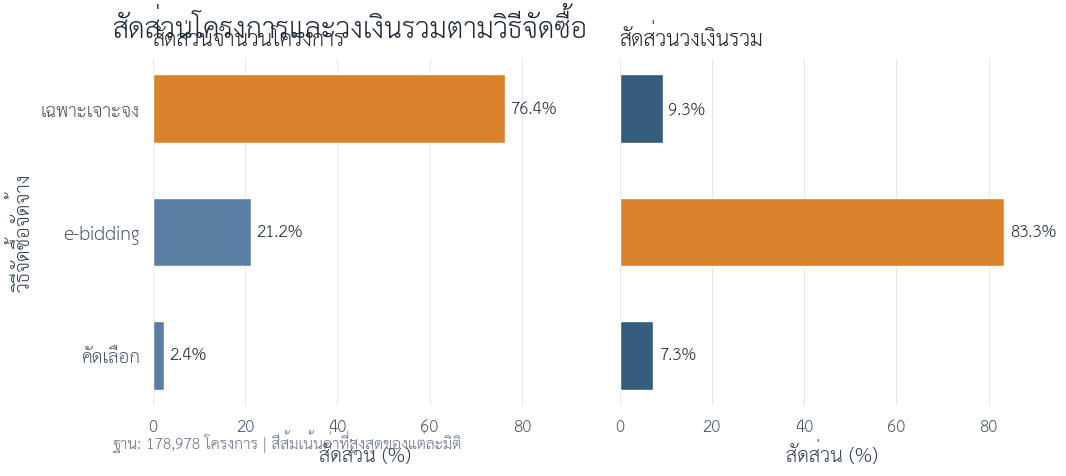

In [76]:
method_plot = method_plot.sort_values(
    'project_count',
    ascending=False
).reset_index(drop=True)

y = np.arange(len(method_plot))
count_colors = [
    AMBER if method == 'เฉพาะเจาะจง' else BLUE
    for method in method_plot['method_label']
]
value_colors = [
    AMBER if method == 'e-bidding' else NAVY
    for method in method_plot['method_label']
]

fig, axes = plt.subplots(
    ncols=2,
    figsize=(11.5, 4.5),
    sharey=True,
    gridspec_kw={'wspace': 0.10}
)

count_bars = axes[0].barh(
    y,
    method_plot['project_pct'],
    color=count_colors,
    height=0.56
)

value_bars = axes[1].barh(
    y,
    method_plot['budget_pct'],
    color=value_colors,
    height=0.56
)

for ax, bars, values, panel_title in zip(
    axes,
    [count_bars, value_bars],
    [method_plot['project_pct'], method_plot['budget_pct']],
    ['สัดส่วนจำนวนโครงการ', 'สัดส่วนวงเงินรวม']
):
    ax.bar_label(
        bars,
        labels=[f'{value:.1f}%' for value in values],
        padding=4,
        fontsize=12,
        color=TEXT
    )
    ax.set_title(panel_title, loc='left', fontsize=15, pad=10)
    ax.set_xlabel('สัดส่วน (%)')
    ax.set_xlim(0, 92)
    ax.grid(axis='x', color=GRID, linewidth=0.8)
    ax.grid(axis='y', visible=False)
    ax.set_axisbelow(True)
    sns.despine(ax=ax, left=True, bottom=True)

axes[0].set_yticks(y)
axes[0].set_yticklabels(method_plot['method_label'])
axes[0].invert_yaxis()
axes[0].set_ylabel('วิธีจัดซื้อจัดจ้าง')
axes[1].tick_params(axis='y', left=False, labelleft=False)

fig.suptitle(
    'สัดส่วนโครงการและวงเงินรวมตามวิธีจัดซื้อ',
    x=0.09,
    y=0.99,
    ha='left',
    fontsize=20,
    fontweight='semibold',
    color=TEXT
)

fig.text(
    0.09,
    0.015,
    f'ฐาน: {len(project_data):,} โครงการ | สีส้มเน้นค่าที่สูงสุดของแต่ละมิติ',
    fontsize=11,
    color=MUTED
)

fig.tight_layout(rect=[0.07, 0.06, 1, 0.93])

In [77]:
png_path = figure_dir / 'fig03_03_project_and_budget_share_by_method.png'
svg_path = figure_dir / 'fig03_03_project_and_budget_share_by_method.svg'

fig.savefig(png_path, dpi=180, bbox_inches='tight', facecolor='white')
fig.savefig(svg_path, bbox_inches='tight', facecolor='white')

print(f'Saved: {png_path}')
print(f'Saved: {svg_path}')

Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_03_project_and_budget_share_by_method.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_03_project_and_budget_share_by_method.svg


### สิ่งที่พบ

วิธีเฉพาะเจาะจงคิดเป็น 76.4% ของจำนวนโครงการ แต่คิดเป็น 9.3% ของวงเงินรวม ขณะที่ e-bidding มี 21.2% ของจำนวนโครงการ แต่ครอง 83.3% ของวงเงินรวม

ผลนี้แยกให้เห็นชัดว่า “วิธีที่ใช้บ่อยที่สุด” ไม่ใช่ “วิธีที่มีมูลค่ารวมสูงที่สุด” และนำไปสู่คำถามว่าเหตุใดโครงการขนาดเล็กจึงกระจุกอยู่ในวิธีเฉพาะเจาะจง

## 5. กฎหมายอธิบายการกระจุกอย่างไร

เมื่อย้อนผลจากข้อมูลไปเทียบกับกฎหมาย พบว่า:

- พระราชบัญญัติการจัดซื้อจัดจ้างฯ พ.ศ. 2560 มาตรา 55 กำหนดวิธีจัดซื้อจัดจ้างพัสดุ 3 วิธี ได้แก่ วิธีประกาศเชิญชวนทั่วไป วิธีคัดเลือก และวิธีเฉพาะเจาะจง
- มาตรา 56 วรรคหนึ่ง (2)(ข) เปิดให้ใช้วิธีเฉพาะเจาะจงกับพัสดุทั่วไป เมื่อวงเงินต่อครั้งไม่เกินวงเงินที่กำหนดในกฎกระทรวง
- กฎกระทรวงกำหนดวงเงินดังกล่าวไว้ไม่เกิน 500,000 บาท

แหล่งอ้างอิง: [พระราชบัญญัติการจัดซื้อจัดจ้างฯ ในราชกิจจานุเบกษา](https://www.ratchakitcha.soc.go.th/) และ [กฎหมาย/ระเบียบด้านการจัดซื้อจัดจ้างของกรมบัญชีกลาง](https://www.cgd.go.th/)

ดังนั้น การกระจุกของวิธีเฉพาะเจาะจงใต้ 500,000 บาทเป็นรูปแบบเชิงโครงสร้างที่กฎหมายอธิบายได้ ไม่ใช่ anomaly ด้วยตัวเอง

## 6. กำหนดกลุ่มศึกษาหลัก

เพื่อค้นหา Pattern ที่กฎหมายยังอธิบายไม่ได้ จะเปรียบเทียบโครงการภายใต้บริบทเดียวกัน คือวิธีเฉพาะเจาะจงและวงเงินไม่เกิน 500,000 บาท

In [78]:
under_500k_mask = project_data[budget_column] <= 500_000

study_population_mask = (under_500k_mask & project_data[method_column].eq('เฉพาะเจาะจง'))

project_data['is_study_population'] = study_population_mask
study_project_data = project_data[study_population_mask].copy()

study_scope = pd.DataFrame({
    'ขั้นการเลือกข้อมูล': [
        'โครงการก่อสร้างทั้งหมด',
        'วงเงินไม่เกิน 500,000 บาท',
        'เฉพาะเจาะจงและไม่เกิน 500,000 บาท'
    ],
    'project_count': [
        len(project_data),
        under_500k_mask.sum(),
        len(study_project_data)
    ]
})

study_scope['project_pct'] = (study_scope['project_count'] / len(project_data) * 100)

display(study_scope)

,ขั้นการเลือกข้อมูล,project_count,project_pct
0,โครงการก่อสร้างทั้งหมด,178978,100.00
1,"วงเงินไม่เกิน 500,000 บาท",136623,76.34
2,"เฉพาะเจาะจงและไม่เกิน 500,000 บาท",136070,76.03


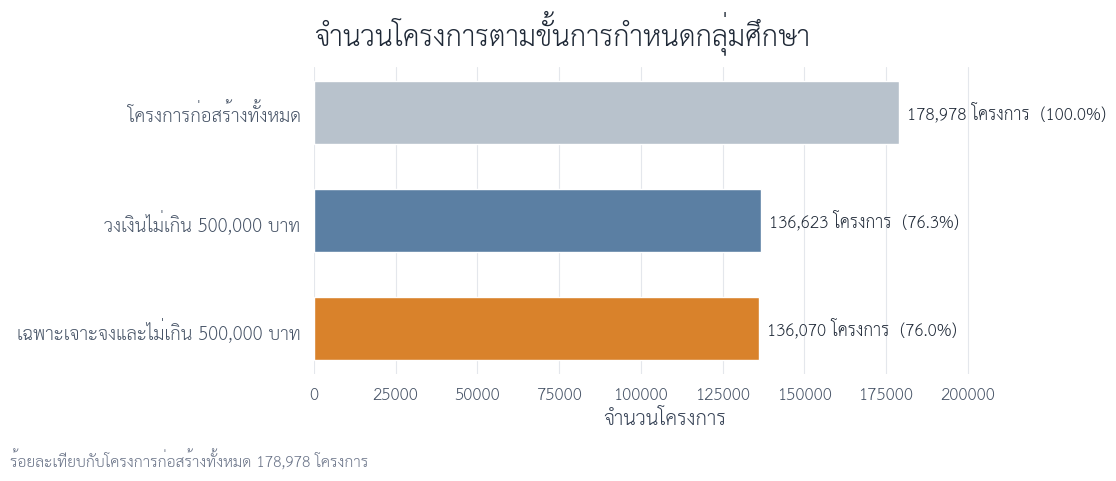

In [79]:
stages = study_scope['ขั้นการเลือกข้อมูล']
counts = study_scope['project_count']
percentages = study_scope['project_pct']
colors = [GRAY, BLUE, AMBER]
y = np.arange(len(study_scope))

fig, ax = plt.subplots(figsize=(11, 4.8))

bars = ax.barh(
    y,
    counts,
    color=colors,
    height=0.58
)

labels = [
    f'{count:,.0f} โครงการ  ({pct:.1f}%)'
    for count, pct in zip(counts, percentages)
]

ax.bar_label(
    bars,
    labels=labels,
    padding=6,
    fontsize=12,
    color=TEXT
)

ax.set_yticks(y)
ax.set_yticklabels(stages)
ax.invert_yaxis()
ax.set_xlim(0, counts.max() * 1.20)

ax.set_title(
    'จำนวนโครงการตามขั้นการกำหนดกลุ่มศึกษา',
    loc='left',
    pad=16,
    color=TEXT
)
ax.set_xlabel('จำนวนโครงการ')
ax.set_ylabel('')

ax.grid(axis='x', color=GRID, linewidth=0.8)
ax.grid(axis='y', visible=False)
ax.set_axisbelow(True)
sns.despine(left=True, bottom=True)

fig.text(
    0.01,
    0.01,
    f'ร้อยละเทียบกับโครงการก่อสร้างทั้งหมด {len(project_data):,} โครงการ',
    fontsize=11,
    color=MUTED
)

fig.tight_layout(rect=[0, 0.05, 1, 1])

In [80]:
png_path = figure_dir / 'fig03_04_study_scope_selection.png'
svg_path = figure_dir / 'fig03_04_study_scope_selection.svg'

fig.savefig(png_path, dpi=180, bbox_inches='tight', facecolor='white')
fig.savefig(svg_path, bbox_inches='tight', facecolor='white')

print(f'Saved: {png_path}')
print(f'Saved: {svg_path}')

Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_04_study_scope_selection.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_04_study_scope_selection.svg


### ผลการกำหนดขอบเขต

กลุ่มศึกษาลดจากโครงการก่อสร้างทั้งหมด 178,978 โครงการ เหลือ 136,623 โครงการที่มีวงเงินไม่เกิน 500,000 บาท และเหลือ 136,070 โครงการเมื่อจำกัดเฉพาะวิธีเฉพาะเจาะจง

การกำหนดขอบเขตนี้ไม่ได้หมายความว่า 136,070 โครงการผิดปกติ แต่ทำให้การค้นหา Pattern เปรียบเทียบโครงการที่อยู่ภายใต้เงื่อนไขกฎหมายเดียวกัน


In [81]:
project_data.to_csv(
    project_output_path,
    index=False,
    encoding='utf-8-sig'
)

print(f'Project rows saved: {len(project_data):,}')
print(f'Study population: {len(study_project_data):,}')
print(f'Saved to: {project_output_path}')


Project rows saved: 178,978
Study population: 136,070
Saved to: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed/construction_projects_2569.csv


## 7. สรุปและคำถามส่งต่อ

สิ่งที่กฎหมายอธิบายได้คือ การใช้วิธีเฉพาะเจาะจงและการกระจุกใต้เพดาน 500,000 บาท ส่วนสิ่งที่กฎหมายยังไม่อธิบายคือ:

- เหตุใดบางคู่หน่วยงาน–ผู้รับจ้างจึงมีหลายโครงการใกล้เพดานในวันเดียวกัน
- เหตุใดบางหน่วยงานย่อยจึงพึ่งพาผู้รับจ้างรายเดียวในสัดส่วนสูง

Notebook 04 จะเริ่มจากกลุ่มศึกษา 136,070 โครงการ และตรวจสอง Pattern นี้ โดยใช้ `เลขประจำตัวนิติบุคคล 13 หลัก` เป็นคีย์ผู้รับจ้าง ส่วนชื่อผู้ชนะใช้เพื่อแสดงผลเท่านั้น
